In [58]:
import os
import pandas as pd
import numpy as np

cc18_info = pd.read_csv("package_metadata/cc18_information.csv", sep=";")
cc18_info['task'] = "classification"
ctr23_info = pd.read_csv("package_metadata/ctr23_information.csv", sep=";")
ctr23_info['task'] = "regression"

cc18_ctr23_info = pd.concat([cc18_info, ctr23_info], ignore_index=True, join='outer')
cc18_ctr23_info = cc18_ctr23_info.fillna("no info")

In [59]:
def read_all_experiment_results_data():
    root_path = "package_metadata/openml"
    target_folders = ["kernels_iid_comparison", "other_baselines"]

    experiment_results = []

    if os.path.exists(root_path):
        for dataset_name in os.listdir(root_path):
            dataset_full_path = os.path.join(root_path, dataset_name)
            if os.path.isdir(dataset_full_path):
                for folder_name in target_folders:
                    target_path = os.path.join(dataset_full_path, folder_name)
                    if os.path.exists(target_path):
                        for filename in os.listdir(target_path):
                            if filename.endswith(".csv"):
                                file_path = os.path.join(target_path, filename)
                                try:
                                    df = pd.read_csv(file_path)

                                    # EXTRACT MODEL NAME FROM FILENAME ---
                                    if "_ann" in filename:
                                        df["model_name"] = "nn"
                                    elif "_xgboost" in filename:
                                        df["model_name"] = "xgboost"
                                    else:
                                        df["model_name"] = "unknown"

                                    # --- EXISTING COLUMNS LOGIC ---
                                    if "data_modification_method" not in df.columns:
                                        df["data_modification_method"] = "none"

                                    df["dataset_name"] = dataset_name
                                    df['Group'] = df['explainer'].apply(
                                        lambda x: 'large' if x == 'expected_gradients' else 'small'
                                    )
                                    experiment_results.append(df)

                                except Exception as e:
                                    print(f"Error reading file {file_path}: {e}")

    if experiment_results:
        combined_df = pd.concat(experiment_results, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()
    
results = read_all_experiment_results_data()

In [60]:
results = read_all_experiment_results_data()
results = results.replace('Not Needed', 'no info', regex=False)
results = results.replace('Not needed', 'no info', regex=False)

In [61]:
results = pd.merge(
    results,
    cc18_ctr23_info,
    left_on='dataset_name',
    right_on='name',
    how='left'
)

In [62]:
from goodpoints.compress import largest_power_of_four

results['compression_coefficient'] = results.apply(
    lambda row: row['size'] / (largest_power_of_four(row['n_samples_test']) ** 0.5),
    axis=1
)

results = results[results['compression_coefficient'].isin([0.25, 0.5, 1, 2, 4])]

In [63]:
def get_explainer_total(row):
    ex = row['explainer']
    st = row['strategy']

    if ex == 'expected_gradients':
        return 'expected_gradients'

    elif ex == 'shap' and st == 'kernel':
        return 'shap_kernel'

    elif ex == 'shapiq' and st == 'kernel':
        return 'shapiq_kernel'

    elif ex == 'sage' and st == 'permutation':
        return 'sage_permutation'

results['explainer_total'] = results.apply(get_explainer_total, axis=1)

In [64]:
def get_method_total(row):
    method = row['method']
    kernel = row['kernel']
    data_modification_method = row['data_modification_method']

    if method == 'iid':
        return 'iid'

    if method == 'arfpy':
        return 'arfpy'

    if method == 'stein_thinning':
        return 'stein_thinning'

    if method == 'influence':
        return 'influence'

    if method == 'kernel_thinning' and data_modification_method == "none":
        return 'kt_' + kernel

    if method == 'kernel_thinning' and data_modification_method != "none":
        return 'kt_' + data_modification_method

    return None

results['method_total'] = results.apply(get_method_total, axis=1)


In [65]:
aggregation_columns = ['mae', 'top_k', 'explanation_time', 'mmd', 'compression_time', 'unique_samples']
group_columns = [col for col in results.columns if col not in aggregation_columns]
group_columns_strat = [col for col in results.columns if col not in aggregation_columns and col != 'size']

grouped = results.groupby(group_columns, as_index=False).agg({
    'mae': ['mean', 'std'],
    'top_k': ['mean', 'std'],
    'explanation_time': ['mean', 'std'],
    'mmd': ['mean', 'std'],
    'compression_time': ['mean', 'std'],
    'unique_samples': ['mean', 'std']
})

grouped.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col
                   for col in grouped.columns]

grouped = grouped.rename(columns={
    col: col.replace('mean', 'mean').replace('std', 'std')
    for col in grouped.columns
})

In [66]:
grouped.columns

Index(['size', 'explainer', 'strategy', 'method', 'kernel', 'g', 'num_bins',
       'target_size', 'model_name', 'data_modification_method', 'dataset_name',
       'Group', 'dataset_id', 'name', 'n_features_before_preprocessing',
       'n_classes', 'n_samples_train', 'n_samples_test',
       'n_features_after_preprocessing', 'f1_ann', 'roc_auc_ann', 'f1_xgboost',
       'roc_auc_xgboost', 'task', 'mse_ann_baseline', 'mse_ann',
       'improvement_ann_percent', 'mse_xgboost_baseline', 'mse_xgboost',
       'improvement_xgboost_percent', 'compression_coefficient',
       'explainer_total', 'method_total', 'mae_mean', 'mae_std', 'top_k_mean',
       'top_k_std', 'explanation_time_mean', 'explanation_time_std',
       'mmd_mean', 'mmd_std', 'compression_time_mean', 'compression_time_std',
       'unique_samples_mean', 'unique_samples_std'],
      dtype='object')

In [67]:
grouped_regression = grouped[grouped['task'] == 'regression'][['dataset_id', 
                                                               'size', 
                                                               'explainer_total', 
                                                               'model_name', 
                                                               'n_samples_train', 
                                                               'n_samples_test', 
                                                               'n_features_after_preprocessing', 
                                                               'improvement_ann_percent', 
                                                               'improvement_xgboost_percent', 
                                                               'compression_coefficient', 
                                                               'method_total', 
                                                               'mae_mean'
                                                               ]]

grouped_classification = grouped[grouped['task'] == 'classification'][['dataset_id', 
                                                               'size', 
                                                               'explainer_total', 
                                                               'model_name', 
                                                               'n_classes',
                                                               'n_samples_train', 
                                                               'n_samples_test', 
                                                               'n_features_after_preprocessing', 
                                                               'f1_ann', 
                                                               'roc_auc_ann', 
                                                               'f1_xgboost', 
                                                               'roc_auc_xgboost',
                                                               'compression_coefficient', 
                                                               'method_total', 
                                                               'mae_mean'
                                                               ]]


In [68]:
config_cols_regression = [
    'dataset_id', 
    'size', 
    'explainer_total', 
    'model_name', 
    'n_samples_train', 
    'n_samples_test', 
    'n_features_after_preprocessing', 
    'improvement_ann_percent', 
    'improvement_xgboost_percent', 
    'compression_coefficient'
]

best_config_df_regression = (
    grouped_regression
    .sort_values(by='mae_mean', ascending=True)
    .drop_duplicates(subset=config_cols_regression)
    .copy()
)

best_config_df_regression = best_config_df_regression.rename(columns={'method_total': 'best_method'})

# select metric for model mse_reduction
conditions = [
    (best_config_df_regression['model_name'] == 'nn'), 
    (best_config_df_regression['model_name'] == 'xgboost')
]
choices = [
    best_config_df_regression['improvement_ann_percent'],
    best_config_df_regression['improvement_xgboost_percent']
]

best_config_df_regression['mse_reduction'] = np.select(conditions, choices, default=0)

# drop not needed columns
cols_to_drop = [
    'dataset_id', 
    'mae_mean', 
    'improvement_ann_percent', 
    'improvement_xgboost_percent'
]

best_config_df_regression = best_config_df_regression.drop(columns=cols_to_drop)

###########################

config_cols_classification = [
    'dataset_id', 
    'size', 
    'explainer_total', 
    'model_name', 
    'n_samples_train', 
    'n_samples_test', 
    'n_features_after_preprocessing', 
    'f1_ann', 
    'roc_auc_ann', 
    'f1_xgboost', 
    'roc_auc_xgboost',
    'compression_coefficient', 
    'n_classes'
]

best_config_df_classification = (
    grouped_classification
    .sort_values(by='mae_mean', ascending=True)
    .drop_duplicates(subset=config_cols_classification)
    .copy()
)

best_config_df_classification = best_config_df_classification.rename(columns={'method_total': 'best_method'})

# select metrics
conditions_clf = [
    (best_config_df_classification['model_name'] == 'nn'), 
    (best_config_df_classification['model_name'] == 'xgboost')
]

f1_choices = [
    best_config_df_classification['f1_ann'], 
    best_config_df_classification['f1_xgboost']
]

roc_auc_choices = [
    best_config_df_classification['roc_auc_ann'], 
    best_config_df_classification['roc_auc_xgboost']
]

best_config_df_classification['f1_score'] = np.select(conditions_clf, f1_choices, default=0)
best_config_df_classification['roc_auc_score'] = np.select(conditions_clf, roc_auc_choices, default=0)

cols_to_drop_clf = [
    'dataset_id', 
    'mae_mean', 
    'f1_ann', 
    'roc_auc_ann', 
    'f1_xgboost', 
    'roc_auc_xgboost'
]

best_config_df_classification = best_config_df_classification.drop(columns=cols_to_drop_clf)


In [69]:
best_config_df_classification

,size,explainer_total,model_name,n_classes,n_samples_train,n_samples_test,n_features_after_preprocessing,compression_coefficient,best_method,f1_score,roc_auc_score
7914,512,sage_permutation,nn,2.0,72240,24080,21,4.00,kt_gaussian,0.590151,0.528064
7319,256,sage_permutation,nn,2.0,72240,24080,21,2.00,kt_predictions,0.590151,0.528064
5970,128,sage_permutation,nn,2.0,72240,24080,21,1.00,kt_predictions,0.590151,0.528064
4244,64,sage_permutation,nn,2.0,72240,24080,21,0.50,kt_inverse_multiquadric,0.590151,0.528064
2701,32,sage_permutation,nn,2.0,72240,24080,21,0.25,kt_matern,0.590151,0.528064
...,...,...,...,...,...,...,...,...,...,...,...
4181,64,sage_permutation,nn,26.0,14166,4894,16,1.00,kt_gaussian,0.942353,0.999291
979,16,sage_permutation,xgboost,26.0,14166,4894,16,0.25,arfpy,0.960598,0.999563
2762,32,sage_permutation,nn,26.0,14166,4894,16,0.50,kt_predictions,0.942353,0.999291
310,8,sage_permutation,nn,10.0,8244,2748,16,0.25,stein_thinning,0.99527,0.999338


# Tree predicting best model

### Regression

In [70]:
best_config_df_regression

,size,explainer_total,model_name,n_samples_train,n_samples_test,n_features_after_preprocessing,compression_coefficient,best_method,mse_reduction
5829,128,sage_permutation,nn,7807,2635,9,4.00,kt_inverse_multiquadric,87.23
4351,64,sage_permutation,nn,7807,2635,9,2.00,kt_predictions,87.23
7773,256,shapiq_kernel,nn,16077,5486,11,4.00,kt_matern,38.23
6873,128,shapiq_kernel,nn,7807,2635,9,4.00,kt_matern,87.23
2748,32,sage_permutation,nn,7807,2635,9,1.00,kt_predictions,87.23
...,...,...,...,...,...,...,...,...,...
247,8,sage_permutation,nn,8950,2984,14,0.25,kt_predictions,99.91
4183,64,sage_permutation,nn,8950,2984,14,2.00,kt_gaussian,99.91
2580,32,sage_permutation,nn,8950,2984,14,1.00,kt_gaussian,99.91
5905,128,sage_permutation,nn,8950,2984,14,4.00,kt_matern,99.91


Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Accuracy: 30.41%
Test Accuracy: 31.13%
                         precision    recall  f1-score   support

            kt_gaussian       0.18      0.23      0.20        13
kt_inverse_multiquadric       0.26      0.38      0.31        24
              kt_matern       0.44      0.32      0.37        34
         kt_predictions       0.34      0.31      0.33        32
         stein_thinning       0.00      0.00      0.00         3

               accuracy                           0.31       106
              macro avg       0.24      0.25      0.24       106
           weighted avg       0.33      0.31      0.31       106



/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

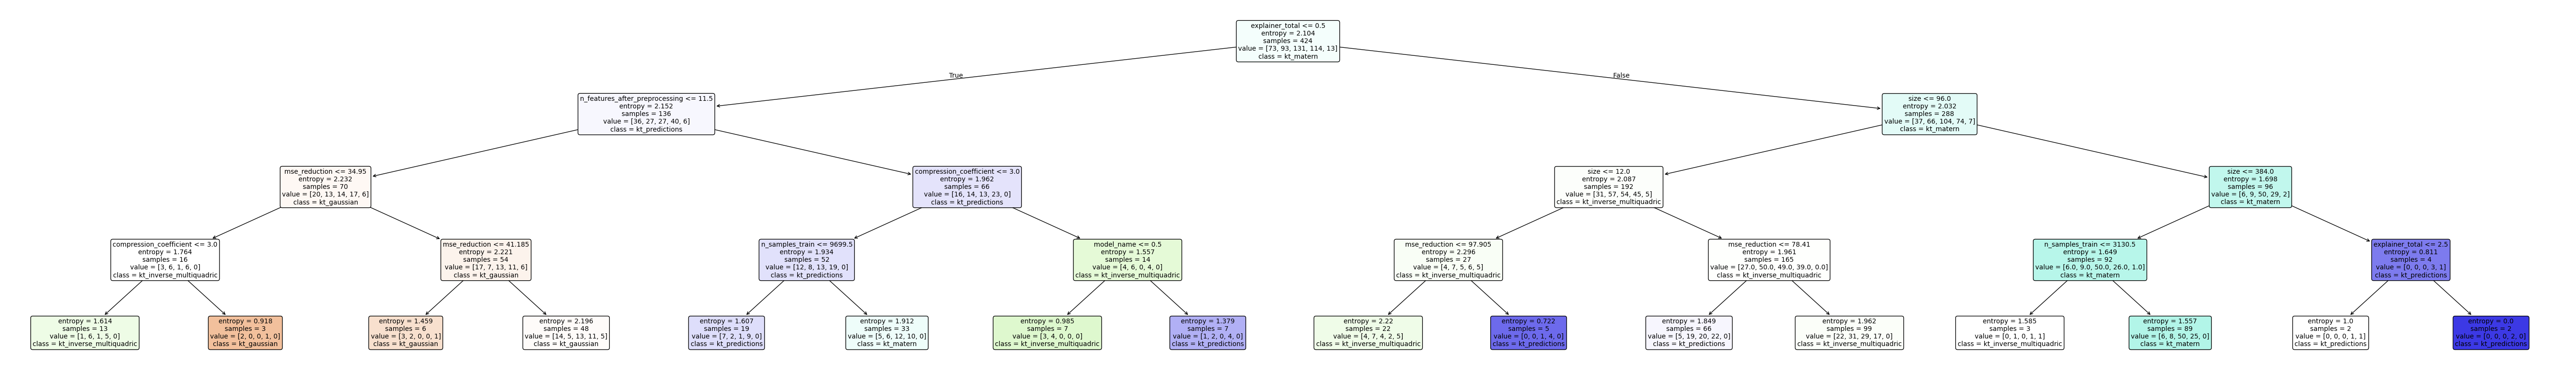

In [73]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

train_df = best_config_df_regression.copy()

le_model = LabelEncoder()
le_explainer = LabelEncoder()
le_method = LabelEncoder()

custom_classes = ['sage_permutation', 'expected_gradients', 'shap_kernel', 'shapiq_kernel']
le_explainer.classes_ = np.array(custom_classes)

train_df['model_name'] = le_model.fit_transform(train_df['model_name'])
train_df['explainer_total'] = le_explainer.transform(train_df['explainer_total'].astype(str))
train_df['best_method'] = le_method.fit_transform(train_df['best_method'])

X = train_df.drop(columns=['best_method'])
y = train_df['best_method']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6, 7],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [2, 3, 4, 5],
    'min_samples_split': [2, 3, 4, 5]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.2%}")

y_pred_best = best_clf.predict(X_test)



print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best):.2%}")
print(classification_report(
    y_test, 
    y_pred_best, 
    labels=range(len(le_method.classes_)),
    target_names=le_method.classes_
))

plt.figure(figsize=(70, 10))
plot_tree(
    best_clf,
    feature_names=X.columns,
    class_names=le_method.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [74]:
for name, le in [('Model', le_model), ('Explainer', le_explainer), ('Method', le_method)]:
    print(f"--- {name} codes ---")
    for i, category in enumerate(le.classes_):
        print(f"{i}: {category}")
    print()

--- Model codes ---
0: nn
1: xgboost

--- Explainer codes ---
0: sage_permutation
1: expected_gradients
2: shap_kernel
3: shapiq_kernel

--- Method codes ---
0: kt_gaussian
1: kt_inverse_multiquadric
2: kt_matern
3: kt_predictions
4: stein_thinning



### Classification

In [75]:
best_config_df_classification

,size,explainer_total,model_name,n_classes,n_samples_train,n_samples_test,n_features_after_preprocessing,compression_coefficient,best_method,f1_score,roc_auc_score
7914,512,sage_permutation,nn,2.0,72240,24080,21,4.00,kt_gaussian,0.590151,0.528064
7319,256,sage_permutation,nn,2.0,72240,24080,21,2.00,kt_predictions,0.590151,0.528064
5970,128,sage_permutation,nn,2.0,72240,24080,21,1.00,kt_predictions,0.590151,0.528064
4244,64,sage_permutation,nn,2.0,72240,24080,21,0.50,kt_inverse_multiquadric,0.590151,0.528064
2701,32,sage_permutation,nn,2.0,72240,24080,21,0.25,kt_matern,0.590151,0.528064
...,...,...,...,...,...,...,...,...,...,...,...
4181,64,sage_permutation,nn,26.0,14166,4894,16,1.00,kt_gaussian,0.942353,0.999291
979,16,sage_permutation,xgboost,26.0,14166,4894,16,0.25,arfpy,0.960598,0.999563
2762,32,sage_permutation,nn,26.0,14166,4894,16,0.50,kt_predictions,0.942353,0.999291
310,8,sage_permutation,nn,10.0,8244,2748,16,0.25,stein_thinning,0.99527,0.999338


/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
CV Accuracy: 33.79%
Final Accuracy: 32.95%
                         precision    recall  f1-score   support

                  arfpy       0.00      0.00      0.00         2
                    iid       0.00      0.00      0.00         0
            kt_gaussian       0.17      0.30      0.21        10
kt_inverse_multiquadric       0.32      0.30      0.31        20
              kt_matern       0.50      0.28      0.36        36
         kt_predictions       0.32      0.53      0.40        19
          kt_stratified       0.00      0.00      0.00         0
         stein_thinning       0.00      0.00      0.00         1

               accuracy                           0.33        88
              macro avg       0.16      0.18      0.16        88
           weighted avg       0.36      0.33      0.33        88



/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

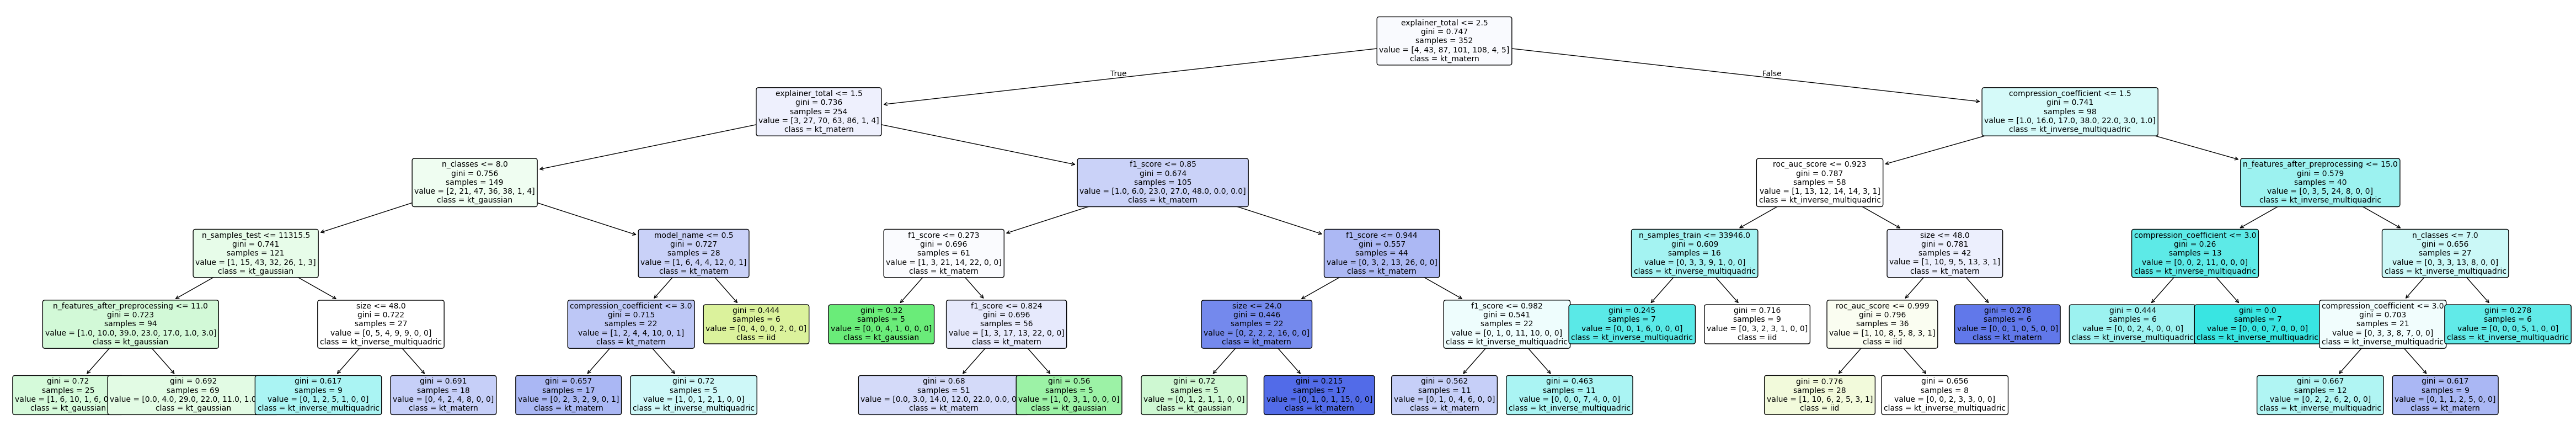

In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

train_df = best_config_df_classification.copy()

le_model = LabelEncoder()
le_explainer = LabelEncoder()
le_method = LabelEncoder()

custom_classes = ['sage_permutation', 'expected_gradients', 'shap_kernel', 'shapiq_kernel']
le_explainer.classes_ = np.array(custom_classes)

train_df['model_name'] = le_model.fit_transform(train_df['model_name'])
train_df['explainer_total'] = le_explainer.transform(train_df['explainer_total'].astype(str))
train_df['best_method'] = le_method.fit_transform(train_df['best_method'])

X = train_df.drop(columns=['best_method'])
y = train_df['best_method']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6, 7],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [2, 3, 4, 5],
    'min_samples_split': [2, 3, 4, 5]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_

print(f"Best parameters: {grid_search.best_params_}")
print(f"CV Accuracy: {grid_search.best_score_:.2%}")

y_pred_best = best_clf.predict(X_test)

print(f"Final Accuracy: {accuracy_score(y_test, y_pred_best):.2%}")
print(classification_report(
    y_test, 
    y_pred_best, 
    labels=range(len(le_method.classes_)),
    target_names=le_method.classes_
))

plt.figure(figsize=(60,10))
plot_tree(best_clf, 
          feature_names=X.columns, 
          class_names=le_method.classes_, 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.show()

In [77]:
for name, le in [('Model', le_model), ('Explainer', le_explainer), ('Method', le_method)]:
    print(f"--- {name} codes ---")
    for i, category in enumerate(le.classes_):
        print(f"{i}: {category}")
    print()

--- Model codes ---
0: nn
1: xgboost

--- Explainer codes ---
0: sage_permutation
1: expected_gradients
2: shap_kernel
3: shapiq_kernel

--- Method codes ---
0: arfpy
1: iid
2: kt_gaussian
3: kt_inverse_multiquadric
4: kt_matern
5: kt_predictions
6: kt_stratified
7: stein_thinning

